In [ ]:
!git clone https://github.com/RanaElBadry/Zar3y.git

Cloning into 'Zar3y'...
remote: Enumerating objects: 11326, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 11326 (delta 13), reused 42 (delta 8), pack-reused 11279 (from 2)
Receiving objects: 100% (11326/11326), 199.91 MiB | 33.27 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (11295/11295), done.


In [ ]:
%cd Zar3y

/content/Zar3y


In [ ]:
import tensorflow as tf
import json

# Load the better format model
model = tf.keras.models.load_model('/content/Zar3y/models/best_model.keras')
print(model.output_shape)

# Load class names from the json
with open('/content/Zar3y/models/label2id.json', 'r') as f:
    label2id = json.load(f)

print(label2id)

(None, 10)
{'Corn_(maize)___Common_rust_': 0, 'Pepper,_bell___Bacterial_spot': 1, 'Pepper,_bell___healthy': 2, 'Potato___Early_blight': 3, 'Potato___Late_blight': 4, 'Potato___healthy': 5, 'Tomato___Early_blight': 6, 'Tomato___Late_blight': 7, 'Tomato___Leaf_Mold': 8, 'Tomato___healthy': 9}


In [ ]:
!pip install opencv-python-headless -q

In [ ]:
!unzip "/content/Zar3y/data/field_photos.zip"

Archive:  /content/Zar3y/data/field_photos.zip
   creating: field_photos/
   creating: field_photos/Corn_(maize)___Common_rust_/
  inflating: field_photos/Corn_(maize)___Common_rust_/photo1.jpg  
  inflating: field_photos/Corn_(maize)___Common_rust_/photo2.jpg  
  inflating: field_photos/Corn_(maize)___Common_rust_/photo3.jpg  
  inflating: field_photos/Corn_(maize)___Common_rust_/photo4.jpg  
   creating: field_photos/Pepper,_bell___Bacterial_spot/
  inflating: field_photos/Pepper,_bell___Bacterial_spot/photo1.jpg  
  inflating: field_photos/Pepper,_bell___Bacterial_spot/photo2.jpg  
  inflating: field_photos/Pepper,_bell___Bacterial_spot/photo3.jpg  
  inflating: field_photos/Pepper,_bell___Bacterial_spot/photo4.jpg  
   creating: field_photos/Pepper,_bell___healthy/
  inflating: field_photos/Pepper,_bell___healthy/photo1.jpg  
  inflating: field_photos/Pepper,_bell___healthy/photo2.jpg  
  inflating: field_photos/Pepper,_bell___healthy/photo4.jpg  
  inflating: field_photos/Pepper,_

In [12]:
!python /content/Zar3y/src/grad_cam.py

Loading model …
2026-05-12 20:14:21.507286: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Classes: ['Corn_(maize)___Common_rust_', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']
Auto-detected last conv layer: 'conv_1' inside 'MobileNetV3Small'
Detected built-in preprocessing layer: 'rescaling_1'. Feeding raw 0-255 pixels.

── PART A: Representative Grad-CAM Examples ──
  Selected 10 representative images (one per class).
  Saved → /content/Zar3y/outputs/grad_cam_examples/Corn_(maize)___Common_rust_.png
  Saved → /content/Zar3y/outputs/grad_cam_examples/Pepper_bell___Bacterial_spot.png
  Saved → /content/Zar3y/outputs/grad_cam_examples/Pepper_bell___healthy.png
  Saved → /content/Zar3y/outputs/grad_cam_examples

/tmp/ipykernel_4066/442588962.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


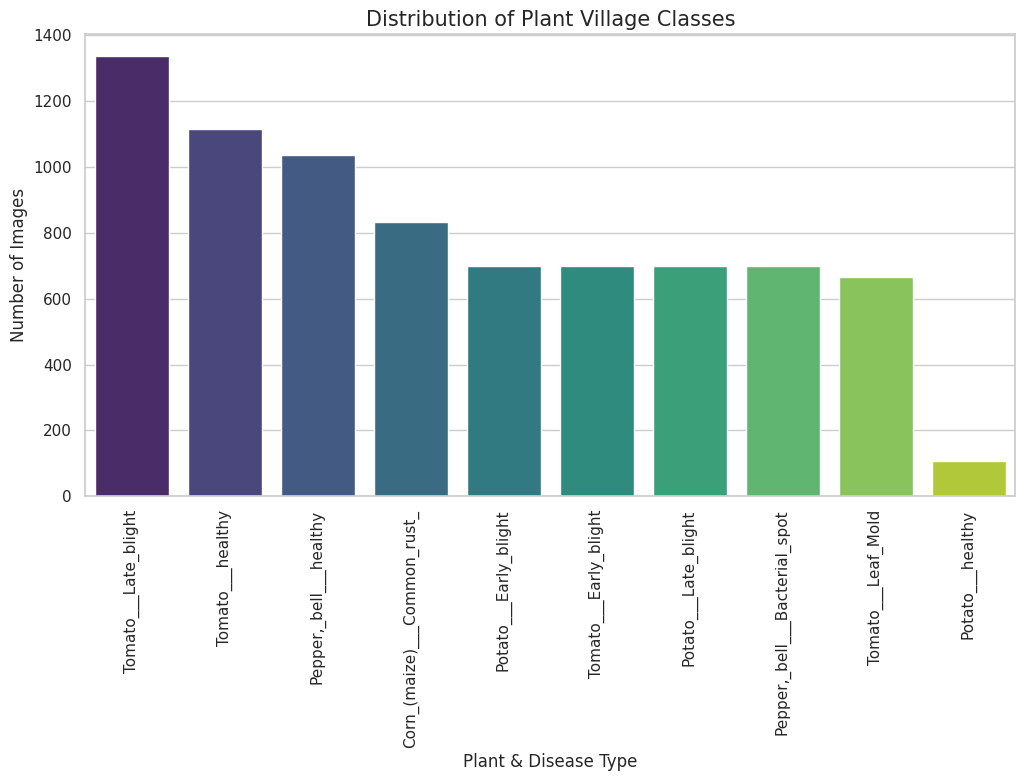

Exact counts per class:
label
Tomato___Late_blight             1336
Tomato___healthy                 1114
Pepper,_bell___healthy           1035
Corn_(maize)___Common_rust_       834
Potato___Early_blight             700
Tomato___Early_blight             700
Potato___Late_blight              700
Pepper,_bell___Bacterial_spot     698
Tomato___Leaf_Mold                666
Potato___healthy                  106
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the counts (This defines the missing variable)
# Using 'label' because that is the column name in your output
class_counts = df['label'].value_counts()

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# 4. Add labels and formatting
plt.title('Distribution of Plant Village Classes', fontsize=15)
plt.xlabel('Plant & Disease Type', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Rotates labels so they don't overlap (necessary for long names like "Tomato___Leaf_Mold")
plt.xticks(rotation=90)

plt.show()

# 5. Print the exact numbers for reference
print("Exact counts per class:")
print(class_counts)

### OOD Field-Photo Evaluation Discussion

The model achieved **21/40 correct predictions**, giving an **OOD Top-1 accuracy of 52.5%** on the collected field-photo set. This is much lower than the expected performance on the original test dataset, which suggests a clear **domain shift** between the training data and real-world images.

While data augmentation simulates basic geometric and color variations, it cannot fully replicate the biological complexity of real-world field conditions. In practice, the model encounters varying severity levels of infection, where symptoms may appear at different pathological stages. Furthermore, 'out-of-distribution' (OOD) samples collected in the field may contain subtle variations of a disease that do not perfectly align with our labeled classes. Additionally, the presence of overlapping foliage and multiple leaves within a single frame introduces significant noise, leading to spatial confusion that simple augmentation cannot prepare the model for.

Another possible reason is **class imbalance or limited representation** in the training data. Some classes may have been learned more strongly than others, causing the model to favor visually similar or dominant classes. For example, several mistakes occurred between early blight, late blight, leaf mold, and healthy leaves, which can look similar in real images.

The field-photo set is also relatively small, with only **40 images**. Because there are only around four images per class, a few difficult or ambiguous samples can strongly affect the final accuracy. Therefore, this OOD accuracy should be interpreted as an initial robustness test rather than a complete real-world benchmark.

Overall, the result shows that the model can correctly classify some real-world examples, especially clearer images, but it is less reliable under field conditions. Improving real-world performance would require collecting more diverse field images, balancing the dataset, applying stronger augmentation, and fine-tuning the model on photos closer to the target application environment.
